In [ ]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC

# Evaluation
from sklearn.model_selection import train_test_split

import seaborn as sns
import matplotlib.pyplot as plt

from rital_nlp_project.common.utils import load_clean_data
from rital_nlp_project.common.notebook_utils import init_notebook
from rital_nlp_project.common.models.models_eval import eval_pipeline, eval_combination_matrix
from rital_nlp_project.movies.metrics import scoring

init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
texts_movies, classes_movies = load_clean_data("../Dataset/movies_clean.parquet")

### Models

##### Tested models
- SVM 
- Multinomila Naive Bayes
- Logistic regression

##### Granularity
- Characters
- Tokens of size 3 characters
- Words

In [11]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(texts_movies, classes_movies, random_state=42)

#### Combination matrix

In [24]:
max_features = 5000
min_df = 5
max_df = 0.5
vectorizer_list = [
    # ~CountVectorizer but normalized
    TfidfVectorizer(use_idf=False, analyzer="char", ngram_range=(1, 1), max_features=max_features),
    TfidfVectorizer(use_idf=False, analyzer="char_wb", ngram_range=(4, 4), max_features=max_features, min_df=min_df, max_df=max_df),
    TfidfVectorizer(use_idf=False, analyzer="word", ngram_range=(1, 1), max_features=max_features, min_df=min_df, max_df=max_df),
    TfidfVectorizer(use_idf=False, analyzer="word", ngram_range=(1, 3), max_features=max_features, min_df=min_df, max_df=max_df),

    # Proper Tfidf
    TfidfVectorizer(analyzer="char_wb", ngram_range=(4, 4), max_features=max_features, min_df=min_df, max_df=max_df),
    TfidfVectorizer(analyzer="word", ngram_range=(1, 1), max_features=max_features, min_df=min_df, max_df=max_df),
    TfidfVectorizer(analyzer="word", ngram_range=(1, 3), max_features=max_features, min_df=min_df, max_df=max_df),
]

classifier_list = [
    LogisticRegression(max_iter=100),
    MultinomialNB(), 
    LinearSVC(),
    #SVC(kernel="rbf")
]

In [25]:
#results = pd.read_csv("out/baseline_eval_matrix_movies.csv")
results = eval_combination_matrix(texts_movies, classes_movies, vectorizer_list, classifier_list, scoring)
results.to_csv("out/baseline_eval_matrix_movies.csv", index=False)

<Axes: xlabel='classifier', ylabel='vectorizer'>

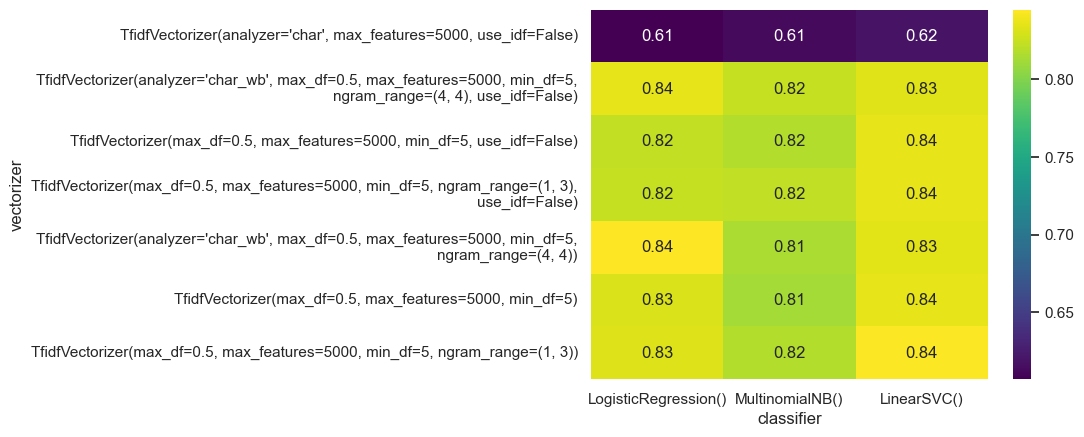

In [26]:
sns.heatmap(results.pivot(columns="classifier", index="vectorizer", values="accuracy"), annot=True, cmap="viridis")

<Axes: xlabel='classifier', ylabel='vectorizer'>

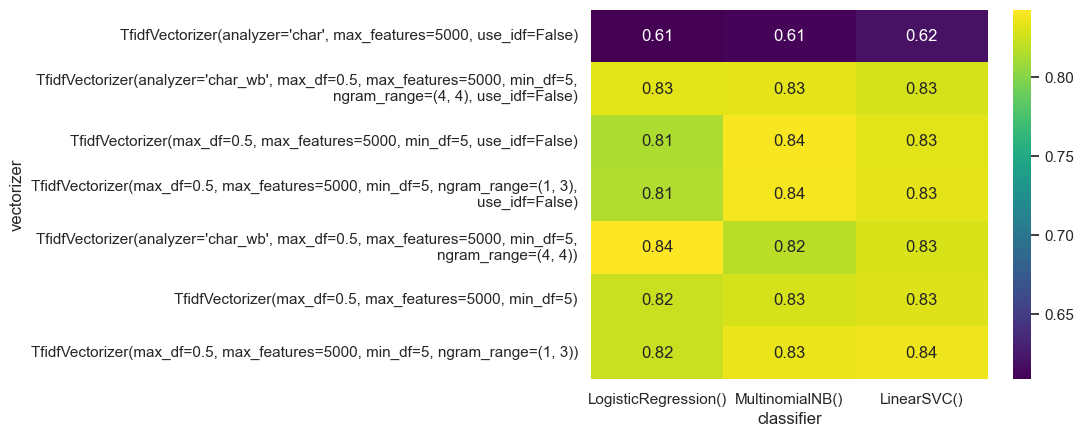

In [27]:
sns.heatmap(results.pivot(columns="classifier", index="vectorizer", values="precision"), annot=True, cmap="viridis")

<Axes: xlabel='classifier', ylabel='vectorizer'>

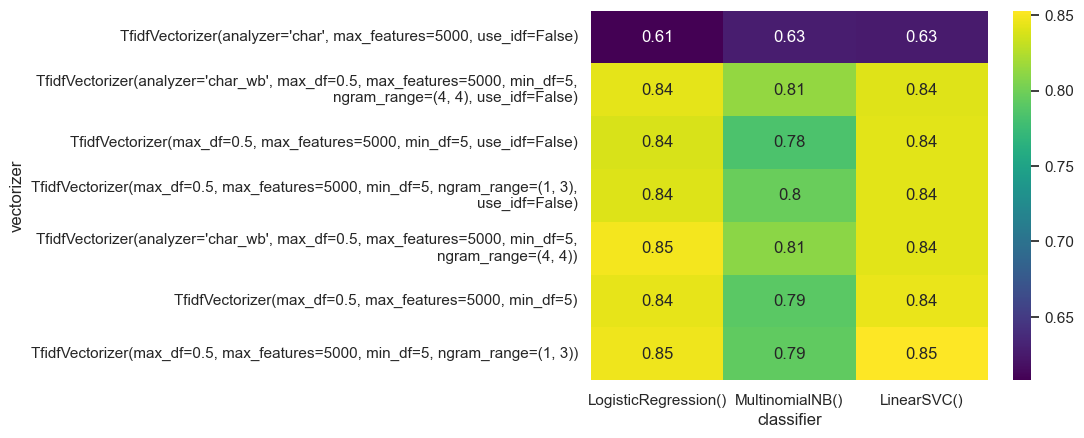

In [28]:
sns.heatmap(results.pivot(columns="classifier", index="vectorizer", values="recall"), annot=True, cmap="viridis")